# Re-import necessary libraries after reset

In [ ]:
import numpy as np
import os
import csv
import pandas as pd
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.stats import spearmanr, kendalltau
import scipy.stats as stats
from scipy.stats import linregress, pearsonr
from scipy.stats import zscore
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from skimage.io import imread
from skimage.color import rgb2gray
from skimage import filters, morphology, measure

# Wulff construction

In [ ]:
# =========================
# PATHS
# =========================
input_folder = "stm_images"
output_folder = "gamma_png"
os.makedirs(output_folder, exist_ok=True)

# Define CSV export folder
csv_export_folder = "gamma_csv"
os.makedirs(csv_export_folder, exist_ok=True)

In [ ]:
# =========================
# PARAMETERS
# =========================
min_size = 50
keep_harmonics = 12
n_theta = 360
angle_labels = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
orange_sectors = [(330, 30), (90, 150), (210, 270)]
blue_sectors = [(30, 90), (150, 210), (270, 330)]

# Convert sector boundaries from degrees to radians
orange_sectors_rad = [(np.deg2rad(start), np.deg2rad(end)) for start, end in orange_sectors]
blue_sectors_rad = [(np.deg2rad(start), np.deg2rad(end)) for start, end in blue_sectors]

In [ ]:
# =========================
# PROCESS EACH IMAGE
# =========================
for fname in os.listdir(input_folder):
    if not fname.endswith((".jpg", ".png")):
        continue
    fpath = os.path.join(input_folder, fname)
    img = imread(fpath)
    img_gray = rgb2gray(img) if img.ndim == 3 else img

    blurred = filters.gaussian(img_gray, sigma=1.0)
    thresh = filters.threshold_otsu(blurred)
    binary = blurred > thresh
    binary = morphology.remove_small_objects(binary, min_size=min_size)
    binary = morphology.binary_closing(binary, morphology.disk(3))

    labels = measure.label(binary)
    props = measure.regionprops(labels)
    if not props:
        print(f"[!] No island found in {fname}")
        continue
    largest = max(props, key=lambda x: x.area)
    contour = max(measure.find_contours(labels == largest.label, 0.5), key=len)
# Add this block here to save image with contour
    fig, ax = plt.subplots()
    ax.imshow(img_gray, cmap='gray')
    ax.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=3, alpha = 1)
    ax.axis('off')
    marked_image_folder = os.path.join("marked_images")
    os.makedirs(marked_image_folder, exist_ok=True)
    marked_image_path = os.path.join(
        marked_image_folder,
        fname.replace('.jpg', '.png').replace('.png', '_marked.png')
    )
    plt.savefig(marked_image_path, dpi=300, bbox_inches='tight', pad_inches=0.0)
    plt.close()
    

# Polar extraction
    cx, cy = contour[:, 1].mean(), contour[:, 0].mean()
    x = contour[:, 1] - cx
    y = contour[:, 0] - cy

    theta_uniform = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    h = np.array([
        np.max(x*np.cos(t) + y*np.sin(t))
        for t in theta_uniform
    ])

    gamma = h / np.mean(h)   # normalized surface-energy anisotropy
    fft_coeffs = fft(gamma)
    fft_coeffs[keep_harmonics:n_theta - keep_harmonics] = 0
    gamma_smoothed = np.real(ifft(fft_coeffs))

# Save polar plot
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
    for start, end in orange_sectors:
        if end < start:
            angles1 = np.linspace(np.deg2rad(start), 2*np.pi, 50)
            angles2 = np.linspace(0, np.deg2rad(end), 50)
            angles = np.concatenate([angles1, angles2])
        else:
            angles = np.linspace(np.deg2rad(start), np.deg2rad(end), 100)
        ax.fill_between(angles, 0, max(gamma_smoothed)*1.2, color='orange', alpha=0.2)
    for start, end in blue_sectors:
        ax.fill_between(np.linspace(np.deg2rad(start), np.deg2rad(end), 100), 0, max(gamma_smoothed)*1.2, color='blue', alpha=0.2)

    ax.plot(theta_uniform, gamma_smoothed, color='black', linewidth=2, label='γ(θ)')
    ax.set_xticks([np.deg2rad(d) for d in angle_labels])
    ax.set_xticklabels([f'{d}°' for d in angle_labels])
    ax.set_title(fname)
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, fname.replace('.jpg', '.png').replace('.png', '_gamma.png')))
    plt.close()

    #print(f"[✓] Processed {fname}")
    
# Save gamma vs theta as CSV
    theta_uniform_deg = np.rad2deg(theta_uniform)
    csv_name = fname.replace(".jpg", "_gamma.csv").replace(".png", "_gamma.csv")
    csv_path = os.path.join(csv_export_folder, csv_name)
    with open(csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Theta", "Gamma"])
        for deg, val in zip(theta_uniform_deg, gamma_smoothed):
            writer.writerow([f"{deg:.0f}", f"{val:.5f}"])

    # print(f"[✓] Exported γ(θ) CSV for {fname}")

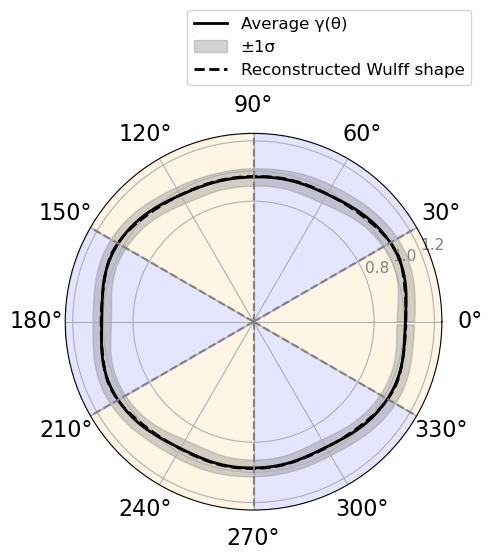

In [9]:
csv_folder = "gamma_csv"          # folder containing per-island CSV files
output_csv = "gamma_mean.csv"     # averaged gamma output
output_fig = "gamma_theta.png"    # final figure

# =========================
# LOAD ALL GAMMA CSV FILES
# =========================
gamma_list = []
theta_vals_deg = None

for file in sorted(os.listdir(csv_folder)):
    if not file.lower().endswith(".csv"):
        continue

    path = os.path.join(csv_folder, file)

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[!] Failed to read {file}: {e}")
        continue

    # clean column names
    df.columns = df.columns.astype(str).str.strip()

    # debug print
    #print(f"{file}: columns = {list(df.columns)}")

    if "Theta" not in df.columns or "Gamma" not in df.columns:
        print(f"[!] Skipping {file}: missing Theta/Gamma columns")
        continue

    try:
        theta_this = df["Theta"].astype(float).values
        gamma_this = df["Gamma"].astype(float).values
    except Exception as e:
        print(f"[!] Skipping {file}: cannot convert Theta/Gamma to float ({e})")
        continue

    if theta_vals_deg is None:
        theta_vals_deg = theta_this
    else:
        # make sure all files have same angle grid
        if len(theta_this) != len(theta_vals_deg) or not np.allclose(theta_this, theta_vals_deg):
            print(f"[!] Skipping {file}: Theta grid does not match")
            continue

    gamma_list.append(gamma_this)

if len(gamma_list) == 0:
    raise ValueError("No valid gamma CSV files found in gamma_csv.")

# =========================
# STACK AND COMPUTE STATS
# =========================
gamma_array = np.vstack(gamma_list)      # shape: (n_islands, n_theta)
gamma_mean = np.mean(gamma_array, axis=0)
gamma_std  = np.std(gamma_array, axis=0)

theta_vals_deg = np.asarray(theta_vals_deg)
theta_rad = np.deg2rad(theta_vals_deg)

# =========================
# SAVE AVERAGE GAMMA CSV
# =========================
gamma_mean_df = pd.DataFrame({
    "Theta_deg": theta_vals_deg,
    "Theta_rad": theta_rad,
    "Gamma_mean": gamma_mean,
    "Gamma_std": gamma_std
})
gamma_mean_df.to_csv(output_csv, index=False)
# print(f"[✓] Saved averaged gamma to {output_csv}")

# =========================
# RECONSTRUCT WULFF SHAPE
# =========================
# If gamma(theta) is the support function h(theta),
# the Wulff boundary in polar radius along direction phi is:
# r(phi) = min_theta [ gamma(theta) / cos(phi - theta) ] for cos(phi-theta) > 0

n_points = len(theta_rad)
r_wulff = np.zeros(n_points)

for i, phi in enumerate(theta_rad):
    cos_vals = np.cos(phi - theta_rad)
    valid = cos_vals > 1e-8
    r_candidates = gamma_mean[valid] / cos_vals[valid]
    r_wulff[i] = np.min(r_candidates)

# normalize for visual comparison
gamma_mean_norm = gamma_mean / np.mean(gamma_mean)
gamma_std_norm = gamma_std / np.mean(gamma_mean)
r_wulff_norm = r_wulff / np.mean(r_wulff)

# =========================
# PLOT
# =========================
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

# sector shading
for start, end in orange_sectors:
    if end < start:
        angles1 = np.linspace(np.deg2rad(start), 2*np.pi, 100)
        angles2 = np.linspace(0, np.deg2rad(end), 100)
        angles = np.concatenate([angles1, angles2])
    else:
        angles = np.linspace(np.deg2rad(start), np.deg2rad(end), 100)
    ax.fill_between(angles, 0, 1.25, color='orange', alpha=0.10)

for start, end in blue_sectors:
    if end < start:
        angles1 = np.linspace(np.deg2rad(start), 2*np.pi, 100)
        angles2 = np.linspace(0, np.deg2rad(end), 100)
        angles = np.concatenate([angles1, angles2])
    else:
        angles = np.linspace(np.deg2rad(start), np.deg2rad(end), 100)
    ax.fill_between(angles, 0, 1.25, color='blue', alpha=0.10)

# average gamma
ax.plot(theta_rad, gamma_mean_norm, color='black', lw=2, label='Average γ(θ)')

# std band
lower = gamma_mean_norm - gamma_std_norm
upper = gamma_mean_norm + gamma_std_norm
ax.fill_between(theta_rad, lower, upper, color='gray', alpha=0.35, label='±1σ')

# Wulff shape
ax.plot(theta_rad, r_wulff_norm, color='black', lw=2, ls='--', label='Reconstructed Wulff shape')

# axis settings
ax.set_xticks([np.deg2rad(d) for d in angle_labels])
ax.set_xticklabels([f"{d}°" for d in angle_labels], fontsize=16)

ax.tick_params(axis='x', pad=10)

ax.set_ylim(0, 1.25)
ax.set_yticks([0.8, 1.0, 1.2])
ax.set_yticklabels(["0.8", "1.0", "1.2"], fontsize=11, color = 'gray')

# dashed guide lines
dashed_angles = [30, 90, 150, 210, 270, 330]
for deg in dashed_angles:
    rad = np.deg2rad(deg)
    ax.plot([rad, rad], [0, 1.25], linestyle='--', color='gray', lw=1.5)

ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.35), fontsize=12)

plt.tight_layout()
plt.savefig(output_fig, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# print(f"[✓] Saved figure to {output_fig}")

# Support line from average gamma

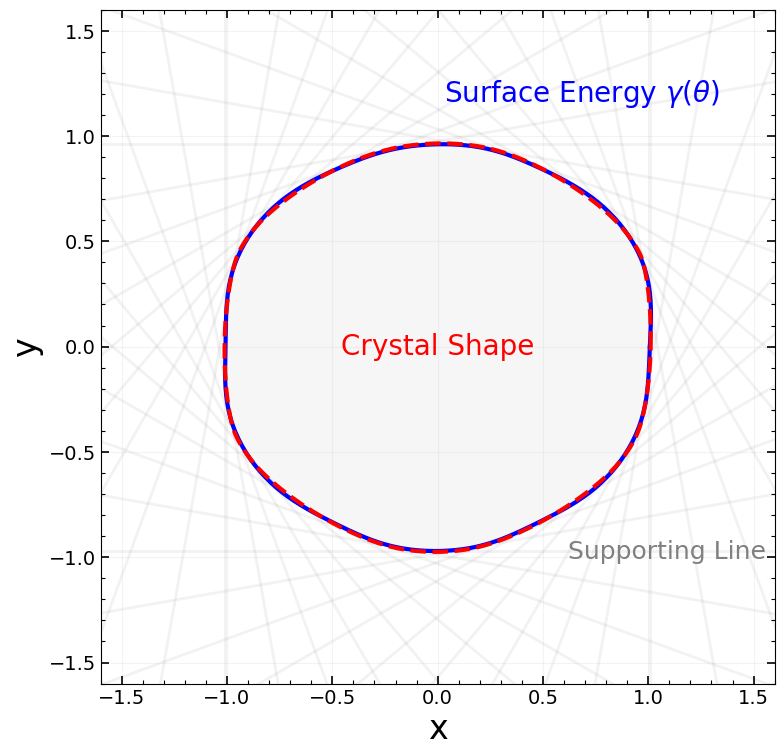

[✓] Saved figure to wulff_full_cartesian.png


In [10]:
output_cartesian_fig = "wulff_full_cartesian.png"

# =========================
# INPUTS FROM YOUR EXISTING SCRIPT
# =========================
# theta_rad         : angle grid in radians
# gamma_mean_norm   : normalized average gamma(theta)
# r_wulff_norm      : normalized reconstructed Wulff radius

gamma_support = gamma_mean_norm.copy()
r_inner = r_wulff_norm.copy()

# =========================
# CONVERT TO CARTESIAN
# =========================
x_gamma = gamma_support * np.cos(theta_rad)
y_gamma = gamma_support * np.sin(theta_rad)

x_wulff = r_inner * np.cos(theta_rad)
y_wulff = r_inner * np.sin(theta_rad)

# close curves
x_gamma_c = np.append(x_gamma, x_gamma[0])
y_gamma_c = np.append(y_gamma, y_gamma[0])

x_wulff_c = np.append(x_wulff, x_wulff[0])
y_wulff_c = np.append(y_wulff, y_wulff[0])


fig, ax = plt.subplots(figsize=(8, 8))

# SUPPORT LINES
# change this if you want more/fewer support lines
theta_support = np.linspace(0, 2*np.pi, 36, endpoint=False)

# safer periodic interpolation
theta_ext = np.concatenate([theta_rad, theta_rad + 2*np.pi])
gamma_ext = np.concatenate([gamma_support, gamma_support])

L = 4.2  # support-line length

for th in theta_support:
    h = np.interp(th, theta_ext, gamma_ext)

    n = np.array([np.cos(th), np.sin(th)])      # outward normal
    t = np.array([-np.sin(th), np.cos(th)])     # tangent direction
    p0 = h * n                                  # point on support line

    s = np.linspace(-L/2, L/2, 300)
    line = p0[None, :] + s[:, None] * t[None, :]

    ax.plot(line[:, 0], line[:, 1], color='gray', lw=2, alpha=0.1, zorder=1)


ax.fill(
    x_wulff_c, y_wulff_c,
    color='lightgray',
    alpha=0.2,
    zorder=3
)


# PLOT 
ax.plot(
    x_gamma_c, y_gamma_c,
    color='blue',
    lw=3.0,
    label=r'$\gamma(\theta)$',
    zorder=5
)

ax.plot(
    x_wulff_c, y_wulff_c,
    color='red',
    linestyle='--',
    lw=3.0,
    label='Wulff shape',
    zorder=6
)


ax.text(
    0.03, 1.20,
    r"Surface Energy $\gamma(\theta)$",
    color='blue',
    fontsize=20,
    ha='left',
    va='center',
    zorder=9
)

ax.text(
    0.62, -1.03,
    "Supporting Line",
    color='gray',
    fontsize=18,
    ha='left',
    va='bottom',
    zorder=9
)

ax.text(
    0.00, 0.00,
    "Crystal Shape",
    color='red',
    fontsize=20,
    ha='center',
    va='center',
    zorder=9
)


# Cosmetics
ax.set_aspect("equal")
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)

tick_vals = np.arange(-1.5, 1.6, 0.5)
ax.set_xticks(tick_vals)
ax.set_yticks(tick_vals)

from matplotlib.ticker import AutoMinorLocator
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))


ax.tick_params(axis='both', which='major', direction='in',
               length=6, width=1.2, labelsize=14)

ax.tick_params(axis='both', which='minor', direction='in',
               length=3, width=0.8)

ax.tick_params(top=True, right=True)
ax.tick_params(which='minor', top=True, right=True)

ax.set_xlabel("x", fontsize=24)
ax.set_ylabel("y", fontsize=24)

# optional: faint grid
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(output_cartesian_fig, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# print(f"[✓] Saved figure to {output_cartesian_fig}")

# Ratio surface energy

[✓] Saved gamma ratio results to gamma_ratio_results.csv


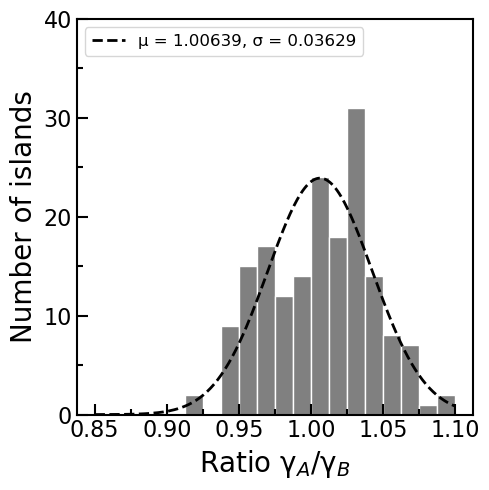

In [12]:
group_A = [30.0, 150.0, 270.0]
group_B = [90.0, 210.0, 330.0]
ratios = []

for fname in os.listdir(csv_folder):
    if not fname.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(csv_folder, fname))
    if "Theta" in df.columns and "Gamma" in df.columns:
        gamma_A = []
        gamma_B = []
        for angle in group_A:
            row = df[np.isclose(df["Theta"], angle, atol=0.5)]
            if not row.empty:
                gamma_A.append(row["Gamma"].values[0])
        for angle in group_B:
            row = df[np.isclose(df["Theta"], angle, atol=0.5)]
            if not row.empty:
                gamma_B.append(row["Gamma"].values[0])
        if len(gamma_A) == 3 and len(gamma_B) == 3:
            ratio = (np.mean(gamma_A) / np.mean(gamma_B))
            ratios.append(ratio)

# Convert to DataFrame and save to CSV
ratio_df = pd.DataFrame(ratios)
output_path = "gamma_ratio_results.csv"
ratio_df.to_csv(output_path, index=False)

# print(f"[✓] Saved gamma ratio results to {output_path}")

# Filter range [0.85, 1.1] and fit Gaussian
filtered_ratios = [r for r in ratios if 0.85 <= r <= 1.1]
mu, std = norm.fit(filtered_ratios)

# Plot histogram with Gaussian fit
plt.figure(figsize=(5, 5))
counts, bins, patches = plt.hist(filtered_ratios, bins=20, range=(0.85, 1.1),
                                 color='gray', edgecolor='white', alpha=1, density=False)

x_fit = np.linspace(0.85, 1.1, 200)
y_fit = len(filtered_ratios) * (bins[1] - bins[0]) * norm.pdf(x_fit, mu, std)
plt.plot(x_fit, y_fit, 'k--', label=f'μ = {mu:.5f}, σ = {std:.5f}', lw = 2)

ax = plt.gca()
#ax.spines['bottom'].set_visible(False)
#ax.spines['left'].set_visible(False)
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('k')
ax.spines['top'].set_color('k') 
ax.spines['right'].set_color('k')
ax.spines['left'].set_color('k')

ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

x_ticks = np.arange(0.85, 1.11, 0.05)
y_ticks = np.arange(0, 41, 10)
plt.xticks(x_ticks, color = 'k')
plt.yticks(y_ticks, color = 'k')
plt.tick_params(axis = 'both', which = 'major', direction = 'in', length = 8, width = 1.5, labelsize = 16)
plt.tick_params(axis = 'both', which = 'minor', direction = 'in', length = 4, width = 1.5, labelsize = 16)
ax.xaxis.set_minor_locator(MultipleLocator(0.025))
ax.yaxis.set_minor_locator(MultipleLocator(5))
#ax.set_xticks([])
#ax.set_yticks([])

plt.xlabel("Ratio γ$_A$/γ$_B$", fontsize=20)
plt.ylabel("Number of islands", fontsize=20)
plt.tight_layout()
plt.legend(loc = 'upper left', fontsize=12)
plt.savefig("gamma_ratio_histogram.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()

# Island area

In [13]:
# Parameters
min_size = 50  # minimum object size to consider
pixel_area_nm2 = 0.00060516

# Collect area results
area_data = []

# Process each image
for fname in sorted(os.listdir(input_folder)):
    if not fname.lower().endswith((".jpg", ".png")):
        continue
    fpath = os.path.join(input_folder, fname)
    img = imread(fpath)
    img_gray = rgb2gray(img) if img.ndim == 3 else img

    blurred = filters.gaussian(img_gray, sigma=1.0)
    thresh = filters.threshold_otsu(blurred)
    binary = blurred > thresh
    binary = morphology.remove_small_objects(binary, min_size=min_size)
    binary = morphology.binary_closing(binary, morphology.disk(3))

    labels = measure.label(binary)
    props = measure.regionprops(labels)
    if props:
        largest = max(props, key=lambda x: x.area)
        area_pixels = largest.area
        area_nm2 = area_pixels * pixel_area_nm2
        area_omega = area_pixels * pixel_area_nm2 * 100 / 25.8
        area_data.append({
            "Image": fname,
            "Island area (pixels)": area_pixels,
            "Island area (nm$^2$)": round(area_nm2, 2),
            "Island area ($\\Omega$)": round(area_omega, 2)
        })

# Create DataFrame
area_df = pd.DataFrame(area_data)
output_path = "island_area.csv"
area_df.to_csv(output_path, index=False)
area_df

,Image,Island area (pixels),Island area (nm$^2$),Island area ($\Omega$)
0,image_001.jpg,67801.0,41.03,159.03
1,image_002.jpg,125346.0,75.85,294.01
2,image_003.jpg,130861.0,79.19,306.95
3,image_004.jpg,46600.0,28.20,109.30
4,image_005.jpg,36046.0,21.81,84.55
...,...,...,...,...
175,image_176.jpg,21886.0,13.24,51.34
176,image_177.jpg,106596.0,64.51,250.03
177,image_178.jpg,45231.0,27.37,106.09
178,image_179.jpg,30587.0,18.51,71.74


# Island area vs. ration surface energy

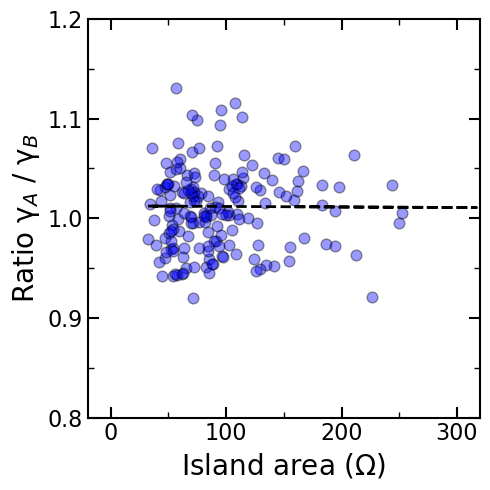

Spearman correlation: 0.0848 (p = 0.2657)
Kendall correlation: 0.0573 (p = 0.2619)


In [88]:
gamma_df = pd.read_csv("gamma_ratio_results.csv")
area = pd.read_csv("island_area.csv")

gamma_col = gamma_df['0']
area_col = area['Island area ($\\Omega$)']

combined_df = pd.DataFrame({
    "Gamma Ratio": gamma_col,
    "Island area (Ω)": area_col
})

slope, intercept, r_value, p_value, std_err = linregress(combined_df["Island area (Ω)"], combined_df["Gamma Ratio"])
regression_line = slope * combined_df["Island area (Ω)"] + intercept

# Compute Z-score
z_scores = np.abs(zscore(combined_df[["Gamma Ratio", "Island area (Ω)"]]))

# Keep only points within threshold
filtered_df = combined_df[(z_scores < 3).all(axis=1)]

# Plotting
plt.figure(figsize=(5, 5))

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_ylim(0.8, 1.2)
ax.set_xlim(-20, 320)

ax.set_xticks(np.arange(0, 320, 100))
ax.set_yticks(np.arange(0.8, 1.21, 0.1))

ax.xaxis.set_minor_locator(MultipleLocator(50))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=16,
    colors='black',
    top=True,
    right=True
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.0,
    colors='black',
    top=True,
    right=True
)

plt.scatter(filtered_df["Island area (Ω)"], filtered_df["Gamma Ratio"], alpha=0.4, color = 'blue', edgecolor = 'k', s = 60 )
plt.plot(combined_df["Island area (Ω)"], regression_line, 'k--', label=f"Fit: y={slope:.3f}x+{intercept:.3f}\n$r$={r_value:.3f}, $p$={p_value:.3f}", lw=2)
plt.xlabel("Island area ($\\Omega$)", fontsize=20)
plt.ylabel("Ratio γ$_A$ / γ$_B$", fontsize=20)
plt.tight_layout()
plt.savefig('ratio_area.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

x = filtered_df["Island area (Ω)"]
y = filtered_df["Gamma Ratio"]

# Compute Spearman correlation
spearman_corr, spearman_p = spearmanr(x, y)

# Compute Kendall correlation
kendall_corr, kendall_p = kendalltau(x, y)

spearman_corr, spearman_p, kendall_corr, kendall_p

print(f"Spearman correlation: {spearman_corr:.4f} (p = {spearman_p:.4g})")
print(f"Kendall correlation: {kendall_corr:.4f} (p = {kendall_p:.4g})")

These results indicate no significant monotonic or ordinal correlation between island area (Ω) and the γₐ/γ_b ratio. The p-values are much greater than 0.05, meaning any observed weak correlation is statistically insignificant. 